# Task A: News Topic Classification — Data Audit & Preparation

**Dataset:** `News_Dataset.csv` (700 articles, NewsAPI-style schema)

This notebook covers:
1. Data inventory & schema audit
2. Parsing nested fields (`source`)
3. Missing value analysis
4. Placeholder/dead-article removal (`[Removed]`)
5. Duplicate detection — including **conflicting-label duplicates**
6. Text field construction & cleaning
7. Label harmonization to the target topic taxonomy
8. Class distribution check
9. Stratified train/val/test split (scikit-learn)
10. Saving processed artifacts

> Note on installing scikit-learn: the PyPI alias package literally named `sklearn` was
> deprecated and now fails on `pip install sklearn`. The library itself is unaffected — install
> it as `pip install scikit-learn`, then import it as `sklearn` as usual (that part never changes).


In [4]:
import pandas as pd
import numpy as np
import ast
import re
from pathlib import Path

from sklearn.model_selection import train_test_split
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

scikit-learn version: 1.9.0


## 0. Configuration

Edit these if your file paths, column names, or label decisions change.


In [5]:
# --- Paths ---
RAW_PATH = Path("./data/News Dataset.csv")
OUTPUT_DIR = Path("./data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Column roles in the raw file ---
COL_TITLE = "title"
COL_DESCRIPTION = "description"
COL_CONTENT = "content"
COL_CATEGORY = "category"
COL_SOURCE = "source"
COL_URL = "url"
COL_PUBLISHED = "publishedAt"

# --- Label harmonization decisions ---
# Raw categories found during profiling: technology, sports, finance, politics,
# education, health, entertainment (100 each, perfectly balanced).
# Target taxonomy per the task brief: Politics, Business, Technology, Health, Sports, Entertainment.
# 'finance' maps cleanly onto 'Business'. 'education' has no home in the 6-label
# taxonomy -- decide explicitly rather than silently dropping or silently keeping it.
DROP_EDUCATION = False   # False -> keep as a 7th class (Education) and note it as an extension.
                         # True  -> drop all education rows, strictly matching the 6-label brief.

CATEGORY_MAP = {
    "technology": "Technology",
    "sports": "Sports",
    "finance": "Business",
    "politics": "Politics",
    "health": "Health",
    "entertainment": "Entertainment",
    "education": "Education",  # only kept if DROP_EDUCATION is False
}

# --- Duplicate-label conflict resolution ---
# Some duplicate titles carry different category labels for the same article (label noise).
# Strategy: for titles with a SINGLE consistent label across all copies, keep one row.
# For titles with CONFLICTING labels across copies, drop all copies (unsafe to guess ground truth).
DROP_CONFLICTING_DUPLICATES = True

# --- Text construction ---
# 'content' in this file is pre-cleaned (lowercased, stopwords stripped, truncated with a
# literal 'chars' suffix) rather than raw article text. We treat title + description as the
# cleanest natural-language signal, and 'content' as a noisier supplementary field.
PRIMARY_TEXT_FIELDS = [COL_TITLE, COL_DESCRIPTION]
INCLUDE_CONTENT_IN_TEXT = False  # set True to also concatenate the pre-cleaned content field

# --- Split ---
TEST_SIZE = 0.15
VAL_SIZE = 0.15  # taken out of the remaining train portion


## 1. Load & Inventory

Basic shape, dtypes, and a first look at the raw rows.


In [6]:
df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape}")
print()
print("Dtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (700, 9)

Dtypes:
source         str
author         str
title          str
description    str
url            str
urlToImage     str
publishedAt    str
content        str
category       str
dtype: object


,source,author,title,description,url,urlToImage,publishedAt,content,category
0,"{'id': None, 'name': 'Yahoo Entertainment'}",Test Yessis,test-setcion,test-setcionThis article originally appeared on Engadget at https://www.engadget.com/technology/computing/test-setci...,https://consent.yahoo.com/v2/collectConsent?sessionId=1_cc-session_b05ec595-0b76-47c5-ace0-4ad77f00e044,NaN,2024-05-14T06:19:29Z,click accept partners including part iab transparency amp consent framework also store access information device wor...,technology
1,"{'id': 'wired', 'name': 'Wired'}",Steven Levy,Don’t Let Mistrust of Tech Companies Blind You to the Power of AI,It’s OK to be doubtful of tech leaders’ grandiose visions of our AI future—but that doesn’t mean the technology won’...,https://www.wired.com/story/dont-let-mistrust-of-tech-companies-blind-you-power-of-ai/,"https://media.wired.com/photos/66625436bd6c904f877d7337/191:100/w_1280,c_limit/Tech-Mistrust-AI-Plaintext-Business-1...",2024-06-07T13:00:00Z,seems evident almost years first conference artificial intelligencewhere nascent fields leaders suggested task would...,technology
2,"{'id': 'wired', 'name': 'Wired'}",Will Knight,OpenAI Offers a Peek Inside the Guts of ChatGPT,"Days after former employees said the company was being too reckless with its technology, OpenAI released a research ...",https://www.wired.com/story/openai-offers-a-peek-inside-the-guts-of-chatgpt/,"https://media.wired.com/photos/6661d484e7f0257b8be9c3d5/191:100/w_1280,c_limit/ChatGPT-Mind-Business-2R5EGF2.jpg",2024-06-06T17:45:55Z,chatgpt developer openais approach building artificial intelligence came fire week former employees accuse company t...,technology


In [11]:
# Null counts per column
null_summary = df_raw.isnull().sum().to_frame("n_missing")
null_summary["pct_missing"] = (null_summary["n_missing"] / len(df_raw) * 100).round(1)
null_summary

,n_missing,pct_missing
source,0,0.0
author,120,17.1
title,0,0.0
description,17,2.4
url,0,0.0
urlToImage,79,11.3
publishedAt,0,0.0
content,0,0.0
category,0,0.0
source_name,0,0.0


In [12]:
# Full duplicate rows (identical across all columns)
n_exact_dupes = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {n_exact_dupes}")

# Duplicate URLs (should be unique per article in a well-formed feed)
print(f"Rows: {len(df_raw)} | Unique URLs: {df_raw[COL_URL].nunique()}")

Fully duplicated rows: 17
Rows: 700 | Unique URLs: 645


## 2. Parse the `source` Field

`source` is stored as a stringified Python dict (e.g. `"{'id': 'wired', 'name': 'Wired'}"`).
Parse it into a plain `source_name` column so it can be used for grouping/EDA (e.g. per-publisher
category tendencies) later.


In [13]:
def parse_source_name(val):
    try:
        d = ast.literal_eval(val)
        return d.get("name")
    except (ValueError, SyntaxError, AttributeError):
        return None

df_raw["source_name"] = df_raw[COL_SOURCE].apply(parse_source_name)
print(f"Unique sources: {df_raw['source_name'].nunique()}")
df_raw["source_name"].value_counts().head(15)

Unique sources: 86


source_name
Business Insider       103
BBC News                97
Yahoo Entertainment     66
ReadWrite               57
The Verge               44
NPR                     35
Wired                   29
CNET                    27
Gizmodo.com             24
[Removed]               23
Time                    18
ABC News                13
Slashdot.org            11
Android Central         10
Hackaday                 8
Name: count, dtype: int64

## 3. Remove Placeholder / Dead Articles

NewsAPI-derived datasets commonly contain `[Removed]` placeholder rows for articles that were
taken down at collection time — these carry no usable text. Identify and drop them.


In [14]:
is_removed = (
    (df_raw[COL_TITLE].str.strip() == "[Removed]")
    | (df_raw["source_name"] == "[Removed]")
    | (df_raw[COL_CONTENT].str.strip().str.lower() == "removed")
)
print(f"Placeholder rows found: {is_removed.sum()}")
print(df_raw.loc[is_removed, COL_CATEGORY].value_counts())

df = df_raw.loc[~is_removed].copy().reset_index(drop=True)
print(f"\nShape after dropping placeholders: {df.shape}")

Placeholder rows found: 23
category
technology       8
sports           5
entertainment    5
health           3
finance          1
education        1
Name: count, dtype: int64

Shape after dropping placeholders: (677, 10)


## 4. Duplicate Detection

Two kinds of duplication matter here:

1. **Clean duplicates** — the same title appears more than once with the *same* category label.
   Safe to collapse to a single row.
2. **Conflicting-label duplicates** — the same title appears with *different* category labels
   across copies. This is label noise (or a genuinely cross-cutting article), and guessing which
   label is "correct" would bias the ground truth. Default strategy: drop all copies.

Both counts are reported before any rows are removed.


In [15]:
title_key = df[COL_TITLE].str.strip().str.lower()
df["_title_key"] = title_key

dup_titles = df[df.duplicated("_title_key", keep=False)].sort_values("_title_key")
n_dup_title_groups = dup_titles["_title_key"].nunique()
print(f"Titles appearing more than once: {n_dup_title_groups} groups ({len(dup_titles)} rows)")

# For each duplicated title, check whether the category label is consistent
label_consistency = dup_titles.groupby("_title_key")[COL_CATEGORY].nunique()
conflicting_titles = label_consistency[label_consistency > 1].index
consistent_titles = label_consistency[label_consistency == 1].index

print(f"  -> consistent label across copies:   {len(consistent_titles)} titles")
print(f"  -> CONFLICTING label across copies:  {len(conflicting_titles)} titles")

Titles appearing more than once: 32 groups (65 rows)
  -> consistent label across copies:   0 titles
  -> CONFLICTING label across copies:  32 titles


In [16]:
# Inspect a sample of conflicting-label duplicates
conflict_examples = dup_titles[dup_titles["_title_key"].isin(conflicting_titles)]
conflict_examples[[COL_TITLE, COL_CATEGORY, "source_name"]].sort_values(COL_TITLE).head(20)

,title,category,source_name
290,A Nonprofit Tried to Fix Tech Culture—but Lost Control of Its Own,politics,Wired
83,A Nonprofit Tried to Fix Tech Culture—but Lost Control of Its Own,technology,Wired
36,A quantum-entangled photon traveled 35 kilometers under the streets of Boston,technology,The Verge
198,A quantum-entangled photon traveled 35 kilometers under the streets of Boston,finance,The Verge
77,ASUS' ZenScreen Smart 27-inch monitor is its first with Google TV,technology,Yahoo Entertainment
615,ASUS' ZenScreen Smart 27-inch monitor is its first with Google TV,entertainment,Yahoo Entertainment
328,Analysis: Where the Salford scrap leaves Starmer and Sunak,politics,BBC News
429,Analysis: Where the Salford scrap leaves Starmer and Sunak,education,BBC News
531,Apple wants to know if you’re hearing things because of tinnitus,health,The Verge
123,Apple wants to know if you’re hearing things because of tinnitus,sports,The Verge


In [17]:
rows_before_dedup = len(df)

if DROP_CONFLICTING_DUPLICATES:
    df = df[~df["_title_key"].isin(conflicting_titles)].copy()

# Collapse remaining (consistent-label) duplicates to a single row per title
df = df.drop_duplicates(subset="_title_key", keep="first").reset_index(drop=True)

dedup_rows_removed = rows_before_dedup - len(df)
print(f"Rows before dedup: {rows_before_dedup}")
print(f"Rows after dedup:  {len(df)}")
print(f"Rows removed:      {dedup_rows_removed}  "
      f"(conflicting-label copies dropped: {DROP_CONFLICTING_DUPLICATES})")

df = df.drop(columns=["_title_key"])

Rows before dedup: 677
Rows after dedup:  612
Rows removed:      65  (conflicting-label copies dropped: True)


## 5. Build the Classification Text Field

Construct a single `text` column to feed downstream models. Per the config above, the default
combines `title` + `description` (natural, unprocessed language). The pre-cleaned `content` field
can optionally be appended — note it has already been lowercased and stripped of stopwords, so
mixing it with raw title/description text means the combined field has inconsistent casing/style;
that's fine for bag-of-words models but worth knowing before using it with anything
case-sensitive (e.g. NER).


In [18]:
def build_text(row):
    parts = [str(row[c]) for c in PRIMARY_TEXT_FIELDS if pd.notna(row[c]) and str(row[c]).strip()]
    if INCLUDE_CONTENT_IN_TEXT and pd.notna(row[COL_CONTENT]):
        parts.append(str(row[COL_CONTENT]))
    return " ".join(parts).strip()

df["text"] = df.apply(build_text, axis=1)

# Flag rows that ended up with little to no usable text
df["text_len_chars"] = df["text"].str.len()
df["text_len_words"] = df["text"].str.split().str.len()

empty_text = df["text_len_chars"].fillna(0) < 10
print(f"Rows with near-empty text (<10 chars): {empty_text.sum()}")
df.loc[empty_text, [COL_TITLE, COL_DESCRIPTION, COL_CATEGORY]]

Rows with near-empty text (<10 chars): 0


,title,description,category


In [19]:
df = df[~empty_text].reset_index(drop=True)
print(f"Shape after dropping near-empty text rows: {df.shape}")
df[["text", "text_len_chars", "text_len_words"]].describe(include="all").T

Shape after dropping near-empty text rows: (612, 13)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
text,612,612,test-setcion test-setcionThis article originally appeared on Engadget at https://www.engadget.com/technology/computi...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_len_chars,612.0,NaN,NaN,NaN,229.95915,70.232394,48.0,174.75,221.0,296.0,390.0
text_len_words,612.0,NaN,NaN,NaN,37.408497,11.736599,7.0,29.0,36.0,47.25,69.0


## 6. Basic Text Cleaning

Light, reversible cleaning only at this stage (encoding artifacts, whitespace, stray HTML/URLs
leaking into title/description). Heavier normalization (lowercasing, stopword removal,
lemmatization) is deferred to the modeling notebook, since different approaches (TF-IDF vs.
transformer vs. LLM zero-shot) want different levels of normalization — doing it here would
force one choice on every downstream method.


In [20]:
URL_RE = re.compile(r"https?://\S+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")

def light_clean(text):
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.replace("\xa0", " ")
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

df["text"] = df["text"].apply(light_clean)
df["text_len_chars"] = df["text"].str.len()
df["text_len_words"] = df["text"].str.split().str.len()

df[["title", "text"]].sample(5, random_state=RANDOM_STATE)

,title,text
81,Porsche builds a hybrid 911 at long last,Porsche builds a hybrid 911 at long last The iconic sports car gets an electrified option as part of the 992-generat...
218,I quit my job at Goldman Sachs to risk it all on a crypto startup. Then the industry crashed.,I quit my job at Goldman Sachs to risk it all on a crypto startup. Then the industry crashed. A trader at Goldman Sa...
55,"Gears are Old and Busted, Capstans are Cool","Gears are Old and Busted, Capstans are Cool Zero backlash, high “gear” reduction, high torque transparency, silent o..."
600,Parents are suing these video game giants over addiction fears,Parents are suing these video game giants over addiction fears A group of American parents is seeking to sue several...
264,Inside the Reluctant Fight to Ban Deepfake Ads,"Inside the Reluctant Fight to Ban Deepfake Ads Without new rules, campaigns could hoodwink voters with AI-generated ..."


## 7. Harmonize Labels to the Target Taxonomy

Map raw `category` values to the target label set using `CATEGORY_MAP` from the config cell.
Any category not present in the map is surfaced explicitly rather than silently dropped.


In [21]:
unmapped = set(df[COL_CATEGORY].unique()) - set(CATEGORY_MAP.keys())
if unmapped:
    print(f"WARNING - categories with no mapping (will become NaN): {unmapped}")

df["label"] = df[COL_CATEGORY].map(CATEGORY_MAP)

if DROP_EDUCATION:
    before_edu = len(df)
    df = df[df["label"] != "Education"].reset_index(drop=True)
    print(f"Dropped Education rows: {before_edu - len(df)}")

# Any row that failed to map should be inspected, not silently discarded
unmapped_rows = df[df["label"].isna()]
if len(unmapped_rows):
    print(f"Rows with unmapped labels: {len(unmapped_rows)}")
    display(unmapped_rows[[COL_TITLE, COL_CATEGORY]])
else:
    print("All rows mapped successfully.")

All rows mapped successfully.


## 8. Class Distribution

Check balance after all filtering — dedup and placeholder removal can shift a dataset that
started perfectly balanced (100/class) away from balance, which matters for model choice
(class weighting, stratified splitting, macro-F1 as the primary metric).


In [22]:
label_counts = df["label"].value_counts()
label_counts_pct = (label_counts / len(df) * 100).round(1)

dist = pd.DataFrame({"count": label_counts, "pct": label_counts_pct})
dist

,count,pct
label,,
Health,90,14.7
Sports,89,14.5
Business,89,14.5
Politics,89,14.5
Education,89,14.5
Entertainment,88,14.4
Technology,78,12.7


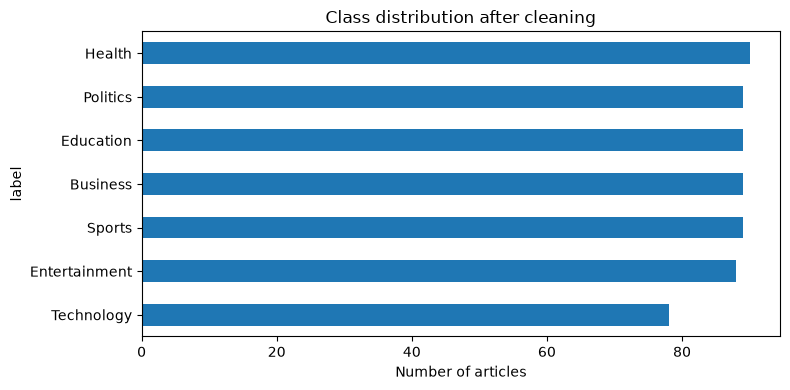

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of articles")
ax.set_title("Class distribution after cleaning")
plt.tight_layout()
plt.show()

## 9. Text Length by Class (sanity check)

A quick check for length-based shortcuts a classifier could exploit (e.g. if one category is
systematically much shorter/longer, a model could partially "cheat" on length alone rather than
content).


In [25]:
df.groupby("label")["text_len_words"].describe()[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
label,,,,,,
Business,89.0,37.617978,11.718774,10.0,35.0,69.0
Education,89.0,38.044944,11.469238,9.0,37.0,66.0
Entertainment,88.0,38.761364,11.243383,12.0,36.0,64.0
Health,90.0,33.544444,11.721641,7.0,32.0,60.0
Politics,89.0,36.101124,11.069045,11.0,35.0,64.0
Sports,89.0,37.977528,12.792023,8.0,36.0,60.0
Technology,78.0,40.205128,11.291140,8.0,40.0,61.0


## 10. Final Cleaned Schema

Keep only the columns needed downstream, with clear names.


In [26]:
final_cols = ["title", "description", "text", "text_len_words", "label",
              "source_name", "publishedAt", "url"]
df_clean = df[final_cols].rename(columns={"publishedAt": "published_at"}).reset_index(drop=True)

print(f"Final shape: {df_clean.shape}")
df_clean.head(3)

Final shape: (612, 8)


,title,description,text,text_len_words,label,source_name,published_at,url
0,test-setcion,test-setcionThis article originally appeared on Engadget at https://www.engadget.com/technology/computing/test-setci...,test-setcion test-setcionThis article originally appeared on Engadget at,8,Technology,Yahoo Entertainment,2024-05-14T06:19:29Z,https://consent.yahoo.com/v2/collectConsent?sessionId=1_cc-session_b05ec595-0b76-47c5-ace0-4ad77f00e044
1,Don’t Let Mistrust of Tech Companies Blind You to the Power of AI,It’s OK to be doubtful of tech leaders’ grandiose visions of our AI future—but that doesn’t mean the technology won’...,Don’t Let Mistrust of Tech Companies Blind You to the Power of AI It’s OK to be doubtful of tech leaders’ grandiose ...,37,Technology,Wired,2024-06-07T13:00:00Z,https://www.wired.com/story/dont-let-mistrust-of-tech-companies-blind-you-power-of-ai/
2,OpenAI Offers a Peek Inside the Guts of ChatGPT,"Days after former employees said the company was being too reckless with its technology, OpenAI released a research ...",OpenAI Offers a Peek Inside the Guts of ChatGPT Days after former employees said the company was being too reckless ...,39,Technology,Wired,2024-06-06T17:45:55Z,https://www.wired.com/story/openai-offers-a-peek-inside-the-guts-of-chatgpt/


## 11. Stratified Train / Validation / Test Split (scikit-learn)

Uses `sklearn.model_selection.train_test_split` with `stratify=` so class proportions are
preserved in every split. The test set is written out and should stay untouched until final
evaluation — including untouched by any LLM labeling experiments in the AI-assisted comparison.


In [27]:
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=TEST_SIZE,
    stratify=df_clean["label"],
    random_state=RANDOM_STATE,
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_size,
    stratify=train_val_df["label"],
    random_state=RANDOM_STATE,
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print()
for name, part in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"--- {name} label distribution (%) ---")
    print((part["label"].value_counts(normalize=True) * 100).round(1).sort_index())
    print()

Train: 428  Val: 92  Test: 92

--- Train label distribution (%) ---
label
Business         14.5
Education        14.7
Entertainment    14.5
Health           14.7
Politics         14.5
Sports           14.5
Technology       12.6
Name: proportion, dtype: float64

--- Val label distribution (%) ---
label
Business         15.2
Education        14.1
Entertainment    14.1
Health           14.1
Politics         14.1
Sports           15.2
Technology       13.0
Name: proportion, dtype: float64

--- Test label distribution (%) ---
label
Business         14.1
Education        14.1
Entertainment    14.1
Health           15.2
Politics         15.2
Sports           14.1
Technology       13.0
Name: proportion, dtype: float64



## 12. Save Processed Artifacts

Write cleaned full dataset plus the three splits to `/mnt/user-data/outputs/` for the next
notebook (EDA / modeling).


In [28]:
df_clean.to_csv(OUTPUT_DIR / "news_clean_full.csv", index=False)
train_df.to_csv(OUTPUT_DIR / "news_train.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "news_val.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "news_test.csv", index=False)

print("Saved:")
for f in ["news_clean_full.csv", "news_train.csv", "news_val.csv", "news_test.csv"]:
    print(f" - {OUTPUT_DIR / f}")

Saved:
 - data/outputs/news_clean_full.csv
 - data/outputs/news_train.csv
 - data/outputs/news_val.csv
 - data/outputs/news_test.csv


## 13. Audit Summary

Quick recap of what changed between raw and clean, for the write-up.


In [36]:
summary = {
    "raw_rows": len(df_raw),
    "placeholder_rows_dropped": int(is_removed.sum()),
    "duplicate_rows_dropped": dedup_rows_removed,
    "near_empty_text_dropped": int(empty_text.sum()),
    "final_rows": len(df_clean),
    "n_classes": df_clean["label"].nunique(),
    "education_kept": not DROP_EDUCATION,
}
summary

{'raw_rows': 92,
 'placeholder_rows_dropped': 23,
 'duplicate_rows_dropped': 65,
 'near_empty_text_dropped': 0,
 'final_rows': 612,
 'n_classes': 7,
 'education_kept': True}

**Note on decisions made in this pass — revisit before modeling:**

- `finance` → `Business`, matching the target taxonomy from the task brief.
- `education` kept as a 7th class by default (`DROP_EDUCATION = False`). If you want to strictly
  match the 6-label brief, set `DROP_EDUCATION = True` and rerun.
- Duplicate titles with **conflicting** category labels were dropped entirely rather than
  guessing which label is correct — inspect the conflict list in Section 4 if you'd rather
  resolve them manually (e.g. by reading the article and picking one).
- `content` was left out of the `text` field by default since it's pre-cleaned/truncated text,
  not raw language — flip `INCLUDE_CONTENT_IN_TEXT` if you want it included as extra signal.
- Package note: install with `pip install scikit-learn` (not `pip install sklearn`, which is a
  deprecated PyPI alias); the import statement `import sklearn` / `from sklearn... import ...`
  is unchanged either way.

Next step: exploratory data analysis (vocabulary overlap between classes, n-gram frequency by
class, source-vs-label patterns) before building the classical TF-IDF baseline.


In [37]:
news_clean = Path("./data/outputs/news_clean_full.csv")
df_raw = pd.read_csv(news_clean)
print(f"Shape: {df_raw.shape}")
print()
print("Dtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (612, 8)

Dtypes:
title               str
description         str
text                str
text_len_words    int64
label               str
source_name         str
published_at        str
url                 str
dtype: object


,title,description,text,text_len_words,label,source_name,published_at,url
0,test-setcion,test-setcionThis article originally appeared on Engadget at https://www.engadget.com/technology/computing/test-setci...,test-setcion test-setcionThis article originally appeared on Engadget at,8,Technology,Yahoo Entertainment,2024-05-14T06:19:29Z,https://consent.yahoo.com/v2/collectConsent?sessionId=1_cc-session_b05ec595-0b76-47c5-ace0-4ad77f00e044
1,Don’t Let Mistrust of Tech Companies Blind You to the Power of AI,It’s OK to be doubtful of tech leaders’ grandiose visions of our AI future—but that doesn’t mean the technology won’...,Don’t Let Mistrust of Tech Companies Blind You to the Power of AI It’s OK to be doubtful of tech leaders’ grandiose ...,37,Technology,Wired,2024-06-07T13:00:00Z,https://www.wired.com/story/dont-let-mistrust-of-tech-companies-blind-you-power-of-ai/
2,OpenAI Offers a Peek Inside the Guts of ChatGPT,"Days after former employees said the company was being too reckless with its technology, OpenAI released a research ...",OpenAI Offers a Peek Inside the Guts of ChatGPT Days after former employees said the company was being too reckless ...,39,Technology,Wired,2024-06-06T17:45:55Z,https://www.wired.com/story/openai-offers-a-peek-inside-the-guts-of-chatgpt/


In [38]:
news_test = Path("./data/outputs/news_test.csv")
df_raw = pd.read_csv(news_test)
print(f"Shape: {df_raw.shape}")
print()
print("Dtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (92, 8)

Dtypes:
title               str
description         str
text                str
text_len_words    int64
label               str
source_name         str
published_at        str
url                 str
dtype: object


,title,description,text,text_len_words,label,source_name,published_at,url
0,Relic Entertainment goes independent,"Relic Entertainment, known for classic game series like Company of Heroes and the Dawn of War franchise, has announc...","Relic Entertainment goes independent Relic Entertainment, known for classic game series like Company of Heroes and t...",40,Entertainment,ReadWrite,2024-05-22T16:12:38Z,https://readwrite.com/relic-entertainment-goes-independent/
1,Tyson 'doing great' after health scare on flight,"Mike Tyson is ""doing great"" following a reported health scare the former heavyweight champion had on a flight from M...","Tyson 'doing great' after health scare on flight Mike Tyson is ""doing great"" following a reported health scare the f...",33,Health,ESPN,2024-05-27T16:42:25Z,https://www.espn.com/boxing/story/_/id/40228916/mike-tyson-doing-great-following-health-scare-flight
2,Trump's jury asked to re-hear the judge's 'rain metaphor' instruction — here's what that might mean,"The ""rain metaphor"" is commonly used in jury instructions to explain how they should infer facts using their common ...","Trump's jury asked to re-hear the judge's 'rain metaphor' instruction — here's what that might mean The ""rain metaph...",36,Business,Business Insider,2024-05-30T15:48:12Z,https://www.businessinsider.com/trump-trial-jury-rain-metaphor-instructions-evidence-2024-5


In [39]:
news_train = Path("./data/outputs/news_train.csv")
df_raw = pd.read_csv(news_train)
print(f"Shape: {df_raw.shape}")
print()
print("Dtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (428, 8)

Dtypes:
title               str
description         str
text                str
text_len_words    int64
label               str
source_name         str
published_at        str
url                 str
dtype: object


,title,description,text,text_len_words,label,source_name,published_at,url
0,A millennial who got laid off says he's encountered ghost jobs and scammers in his struggle to find a remote role,A Utah-based millennial was laid off from his tech job soon after he learned about a worrying health concern. He's s...,A millennial who got laid off says he's encountered ghost jobs and scammers in his struggle to find a remote role A ...,48,Health,Business Insider,2024-05-16T10:03:02Z,https://www.businessinsider.com/millennial-cant-get-hired-remote-jobs-tech-sales-layoffs-health-2024-5
1,Calling France snap election is a gamble for Macron,"Calling a snap election is a huge surprise for France, and a huge risk for President Macron.","Calling France snap election is a gamble for Macron Calling a snap election is a huge surprise for France, and a hug...",26,Politics,BBC News,2024-06-09T21:57:41Z,https://www.bbc.com/news/articles/c8009e2z4xlo
2,"Avowed Gets 30-Minute Deep Dive Revealing Third-Person Gameplay, Abilities","Obsidian Entertainment has posted a 30-minute deep dive for its upcoming fantasy action RPG Avowed, revealing an ext...","Avowed Gets 30-Minute Deep Dive Revealing Third-Person Gameplay, Abilities Obsidian Entertainment has posted a 30-mi...",37,Entertainment,IGN,2024-06-10T18:59:03Z,https://www.ign.com/articles/avowed-gets-30-minute-deep-dive-revealing-third-person-gameplay-abilities


In [40]:
news_val = Path("./data/outputs/news_val.csv")
df_raw = pd.read_csv(news_val)
print(f"Shape: {df_raw.shape}")
print()
print("Dtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (92, 8)

Dtypes:
title               str
description         str
text                str
text_len_words    int64
label               str
source_name         str
published_at        str
url                 str
dtype: object


,title,description,text,text_len_words,label,source_name,published_at,url
0,Conor Kenny Reviews a New Learn-to-Earn Crypto Presale with 100x Potential,"The new Learn-to-Earn token, $99BTC, keeps doing well in its presale, with more experts, including Conor Kenny, cons...","Conor Kenny Reviews a New Learn-to-Earn Crypto Presale with 100x Potential The new Learn-to-Earn token, $99BTC, keep...",51,Education,ReadWrite,2024-06-10T12:40:24Z,https://readwrite.com/conor-kenny-reviews-a-new-learn-to-earn-crypto-presale-with-100x-potential/
1,"Human Infected With Bird Flu in Michigan, Only the Second Case of Current Outbreak","The state of Michigan reported its first human case of H5N1, commonly called the bird flu, on Wednesday according to...","Human Infected With Bird Flu in Michigan, Only the Second Case of Current Outbreak The state of Michigan reported it...",60,Health,Gizmodo.com,2024-05-22T20:14:00Z,https://gizmodo.com/human-bird-flu-h5n1-michigan-outbreak-virus-milk-cows-1851494494
2,Tories unveil GPs plan as Labour makes migration pledge,Laura Kuenssberg will be joined by Health Secretary Victoria Atkins and shadow home secretary Yvette Cooper on Sunday.,Tories unveil GPs plan as Labour makes migration pledge Laura Kuenssberg will be joined by Health Secretary Victoria...,27,Health,BBC News,2024-06-02T04:28:21Z,https://www.bbc.co.uk/news/live/uk-politics-69082668
